<div dir = "rtl">

### فاز ۲: تحلیل اکتشافی داده‌ها (EDA)

هدف این فاز این است که قبل از مدل‌سازی، داده را خوب بشناسیم.

در این مرحله می‌خواهیم بفهمیم:

    روند سالانه بار برق چگونه بوده است
    رفتار هفتگی داده چگونه است
    پیش‌بینی و مقدار واقعی چقدر به هم نزدیک‌اند
    اختلاف بین min/max واقعی و min/max پیش‌بینی‌شده چقدر است
    خطاها در چه بخش‌هایی بیشتر هستند
    آیا الگوی فصلی یا نوسانی خاصی دیده می‌شود

In [2]:
from pathlib import Path
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

project_root = Path.cwd().parent
if str(project_root)not in sys.path:
    sys.path.append(str(project_root))
DATA_DIR = project_root / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
DB_PATH = project_root / "db" / "energy_load.db"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12


<div dir = "rtl">

### چرا از SQLite داده را خواندیم؟

چون در فاز ۱ داده تمیز داخل دیتابیس ذخیره شده است، بهتر است از همین منبع رسمی پروژه استفاده کنیم تا همه مراحل پروژه به هم متصل باشند.

In [3]:
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM weekly_load", conn)
conn.close()

df.head()

,source_file,interval_start,interval_end,week_label,week_number,area_name,area_code,forecast_min_mw,actual_min_mw,actual_max_mw,forecast_max_mw,data_year,created_at
0,GUI_TOTAL_LOAD_YEARAHEAD_201812312300-20191231...,2018-12-31 00:00:00,2019-12-30 00:00:00,Week 1,1,Poland,PL,12898.5,12992.96,24945.56,27700.0,2019,2026-07-06 20:09:35
1,GUI_TOTAL_LOAD_YEARAHEAD_201812312300-20191231...,2018-12-31 00:00:00,2019-12-30 00:00:00,Week 2,2,Poland,PL,14170.9,15513.79,25954.28,27700.0,2019,2026-07-06 20:09:35
2,GUI_TOTAL_LOAD_YEARAHEAD_201812312300-20191231...,2018-12-31 00:00:00,2019-12-30 00:00:00,Week 3,3,Poland,PL,15434.4,15798.93,25264.46,27700.0,2019,2026-07-06 20:09:35
3,GUI_TOTAL_LOAD_YEARAHEAD_201812312300-20191231...,2018-12-31 00:00:00,2019-12-30 00:00:00,Week 4,4,Poland,PL,15483.2,16055.43,26135.58,27700.0,2019,2026-07-06 20:09:35
4,GUI_TOTAL_LOAD_YEARAHEAD_201812312300-20191231...,2018-12-31 00:00:00,2019-12-30 00:00:00,Week 5,5,Poland,PL,15090.6,14985.68,25339.89,27700.0,2019,2026-07-06 20:09:35


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source_file      418 non-null    str    
 1   interval_start   418 non-null    str    
 2   interval_end     418 non-null    str    
 3   week_label       418 non-null    str    
 4   week_number      418 non-null    int64  
 5   area_name        418 non-null    str    
 6   area_code        418 non-null    str    
 7   forecast_min_mw  418 non-null    float64
 8   actual_min_mw    392 non-null    float64
 9   actual_max_mw    392 non-null    float64
 10  forecast_max_mw  418 non-null    float64
 11  data_year        418 non-null    int64  
 12  created_at       418 non-null    str    
dtypes: float64(4), int64(2), str(7)
memory usage: 42.6 KB


In [5]:
df.describe(include="all")

,source_file,interval_start,interval_end,week_label,week_number,area_name,area_code,forecast_min_mw,actual_min_mw,actual_max_mw,forecast_max_mw,data_year,created_at
count,418,418,418,418,418.000000,418,418,418.000000,392.000000,392.000000,418.000000,418.000000,418
unique,8,8,8,53,NaN,1,1,NaN,NaN,NaN,NaN,NaN,1
top,GUI_TOTAL_LOAD_YEARAHEAD_201912312300-20201231...,2019-12-30 00:00:00,2021-01-04 00:00:00,Week 1,NaN,Poland,PL,NaN,NaN,NaN,NaN,NaN,2026-07-06 20:09:35
freq,53,53,53,9,NaN,418,418,NaN,NaN,NaN,NaN,NaN,418
mean,NaN,NaN,NaN,NaN,26.502392,NaN,NaN,13462.969139,13429.639574,23297.144156,24478.667464,2023.129187,NaN
std,NaN,NaN,NaN,NaN,15.098120,NaN,NaN,1293.767174,1310.464944,1731.654566,2004.513311,2.322357,NaN
min,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,10631.400000,10463.962000,19782.762000,19929.000000,2019.000000,NaN
25%,NaN,NaN,NaN,NaN,13.250000,NaN,NaN,12533.700000,12433.455000,22069.958500,23188.000000,2021.250000,NaN
50%,NaN,NaN,NaN,NaN,26.500000,NaN,NaN,13248.000000,13228.580000,23107.892500,24500.000000,2023.500000,NaN
75%,NaN,NaN,NaN,NaN,39.750000,NaN,NaN,14473.375000,14422.543500,24442.357500,26100.000000,2024.750000,NaN


<div dir = "rtl">

### تبدیل نوع داده ها 

In [6]:
df["interval_start"] = pd.to_datetime(df["interval_start"])
df["interval_end"] = pd.to_datetime(df["interval_end"])
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")

<div dir = "rtl">

### ساخت ویژگی‌های کمکی برای EDA

<div dir = "rtl">

### چرا ویژگی‌های جدید ساختیم؟

در EDA فقط خود ستون‌های خام کافی نیستند.

مثلاً برای تحلیل خطا باید این متغیرها را بسازیم:


-    error_min_mw
-    error_max_mw
-    abs_error_min_mw
-    abs_error_max_mw
-    pct_error_min
-    pct_error_max

این متغیرها کمک می‌کنند بفهمیم اختلاف بین مقدار واقعی و پیش‌بینی‌شده چقدر بوده است.

In [7]:
df["actual_range_mw"] = df["actual_max_mw"] - df["actual_min_mw"]
df["forecast_range_mw"] = df["forecast_max_mw"] - df["forecast_min_mw"]

df["error_min_mw"] = df["actual_min_mw"] - df["forecast_min_mw"]
df["error_max_mw"] = df["actual_max_mw"] - df["forecast_max_mw"]

df["abs_error_min_mw"] = df["error_min_mw"].abs()
df["abs_error_max_mw"] = df["error_max_mw"].abs()

df["pct_error_min"] = np.where(
    df["forecast_min_mw"] != 0,
    (df["error_min_mw"] / df["forecast_min_mw"]) * 100,
    np.nan
)

df["pct_error_max"] = np.where(
    df["forecast_max_mw"] != 0,
    (df["error_max_mw"] / df["forecast_max_mw"]) * 100,
    np.nan
)

<div dir = "rtl">

### بررسی مقادیر گمشده

In [8]:
df.isna().sum().sort_values(ascending=False)

abs_error_min_mw     26
pct_error_min        26
abs_error_max_mw     26
actual_max_mw        26
actual_min_mw        26
pct_error_max        26
error_max_mw         26
error_min_mw         26
actual_range_mw      26
source_file           0
week_label            0
interval_end          0
interval_start        0
week_number           0
data_year             0
created_at            0
forecast_min_mw       0
area_name             0
area_code             0
forecast_max_mw       0
forecast_range_mw     0
dtype: int64

<div dir = "rtl">

### روند سالانه

در این بخش میانگین مقادیر هر سال را حساب می‌کنیم تا ببینیم آیا سطح بار برق در طول سال‌ها افزایش یا کاهش داشته است.

همچنین می‌فهمیم دقت پیش‌بینی در طول سال‌ها بهتر شده یا بدتر.

In [9]:
annual_summary = df.groupby("data_year").agg(
    avg_forecast_min=("forecast_min_mw", "mean"),
    avg_actual_min=("actual_min_mw", "mean"),
    avg_forecast_max=("forecast_max_mw", "mean"),
    avg_actual_max=("actual_max_mw", "mean"),
    avg_abs_error_min=("abs_error_min_mw", "mean"),
    avg_abs_error_max=("abs_error_max_mw", "mean"),
    avg_actual_range=("actual_range_mw", "mean"),
    avg_forecast_range=("forecast_range_mw", "mean"),
    count_rows=("data_year", "count")
).reset_index()

annual_summary


,data_year,avg_forecast_min,avg_actual_min,avg_forecast_max,avg_actual_max,avg_abs_error_min,avg_abs_error_max,avg_actual_range,avg_forecast_range,count_rows
0,2019,13718.175000,13649.974808,25384.615385,23601.171731,501.265577,1796.873654,9951.196923,11666.440385,52
1,2021,13602.947170,13311.816415,25683.018868,23005.481321,604.112264,2677.537547,9693.664906,12080.071698,53
2,2022,13175.413462,14069.986923,25886.538462,24204.991538,918.250000,1693.834615,10135.004615,12711.125000,52
3,2023,13982.198077,13979.616154,25028.846154,23828.902692,544.209231,1218.554231,9849.286538,11046.648077,52
4,2024,13389.173077,13235.624038,23832.365385,23016.627087,659.859923,1471.720067,9781.003048,10443.192308,104
5,2025,13101.153846,12674.926019,22974.692308,22373.434923,489.529135,758.181346,9698.508904,9873.538462,52
6,2027,13345.094340,13144.938519,23208.169811,23371.064296,191.775481,255.023185,10226.125778,9863.075472,53


<div dir = "rtl">

### نمودار روند سالانه حداقل بار

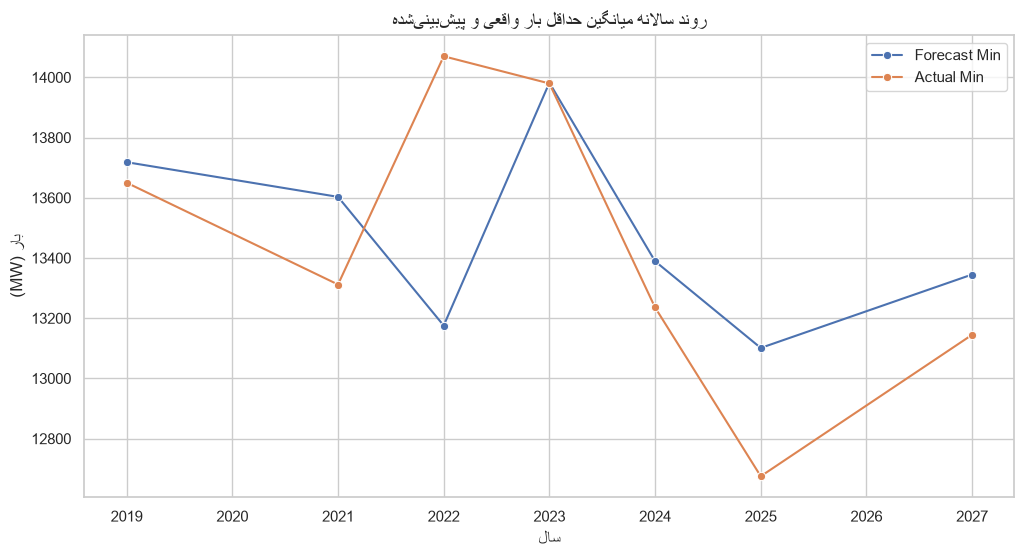

In [10]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=annual_summary, x="data_year", y="avg_forecast_min", marker="o", label="Forecast Min")
sns.lineplot(data=annual_summary, x="data_year", y="avg_actual_min", marker="o", label="Actual Min")
plt.title("روند سالانه میانگین حداقل بار واقعی و پیش‌بینی‌شده")
plt.xlabel("سال")
plt.ylabel("بار (MW)")
plt.legend()
plt.show()


<div dir = "rtl">

### نمودار روند سالانه حداکثر بار

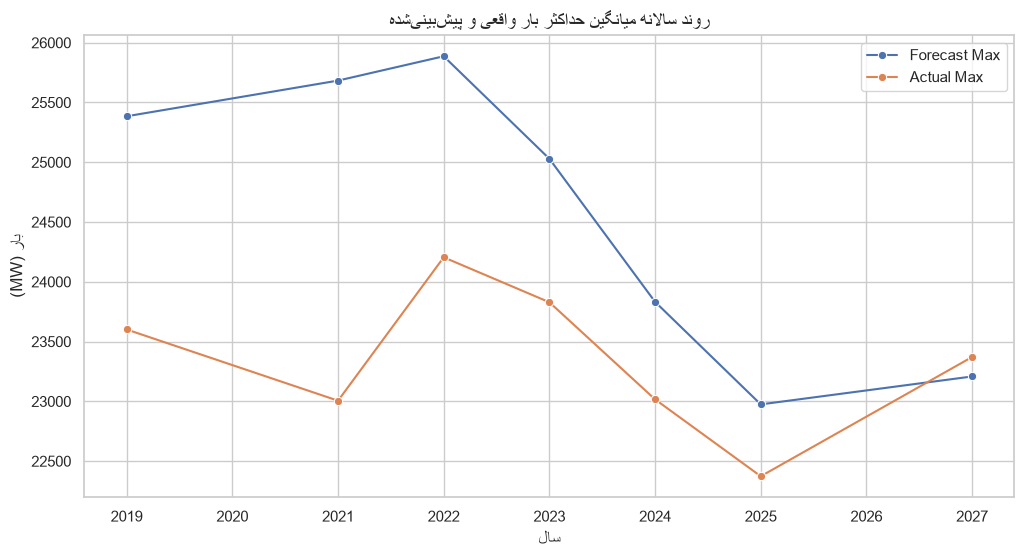

In [11]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=annual_summary, x="data_year", y="avg_forecast_max", marker="o", label="Forecast Max")
sns.lineplot(data=annual_summary, x="data_year", y="avg_actual_max", marker="o", label="Actual Max")
plt.title("روند سالانه میانگین حداکثر بار واقعی و پیش‌بینی‌شده")
plt.xlabel("سال")
plt.ylabel("بار (MW)")
plt.legend()
plt.show()


<div dir = "rtl">

### روند هفتگی 

در این بخش داده‌ها را بر اساس week_number گروه‌بندی می‌کنیم تا الگوهای تکرارشونده در طول هفته‌های سال را ببینیم.

این قسمت برای کشف رفتارهای فصلی بسیار مهم است.

In [12]:
weekly_summary = df.groupby("week_number").agg(
    avg_forecast_min=("forecast_min_mw", "mean"),
    avg_actual_min=("actual_min_mw", "mean"),
    avg_forecast_max=("forecast_max_mw", "mean"),
    avg_actual_max=("actual_max_mw", "mean"),
    avg_abs_error_min=("abs_error_min_mw", "mean"),
    avg_abs_error_max=("abs_error_max_mw", "mean"),
    avg_actual_range=("actual_range_mw", "mean"),
    avg_forecast_range=("forecast_range_mw", "mean"),
).reset_index()

weekly_summary.head()


,week_number,avg_forecast_min,avg_actual_min,avg_forecast_max,avg_actual_max,avg_abs_error_min,avg_abs_error_max,avg_actual_range,avg_forecast_range
0,1,13002.222222,12983.963250,25446.111111,23601.746625,432.581750,2638.401625,10617.783375,12443.888889
1,2,14672.337500,14688.414875,26741.875000,25610.504125,714.064875,1754.724125,10922.089250,12069.537500
2,3,15395.237500,15606.411625,26764.625000,25985.702625,653.900875,1236.832625,10379.291000,11369.387500
3,4,15363.925000,15341.819125,26503.250000,25830.112000,510.910875,926.900000,10488.292875,11139.325000
4,5,15095.750000,15022.517625,26252.125000,25268.439625,469.009875,1395.889625,10245.922000,11156.375000


<div dir = "rtl">

### نمودار روند هفتگی حداقل بار

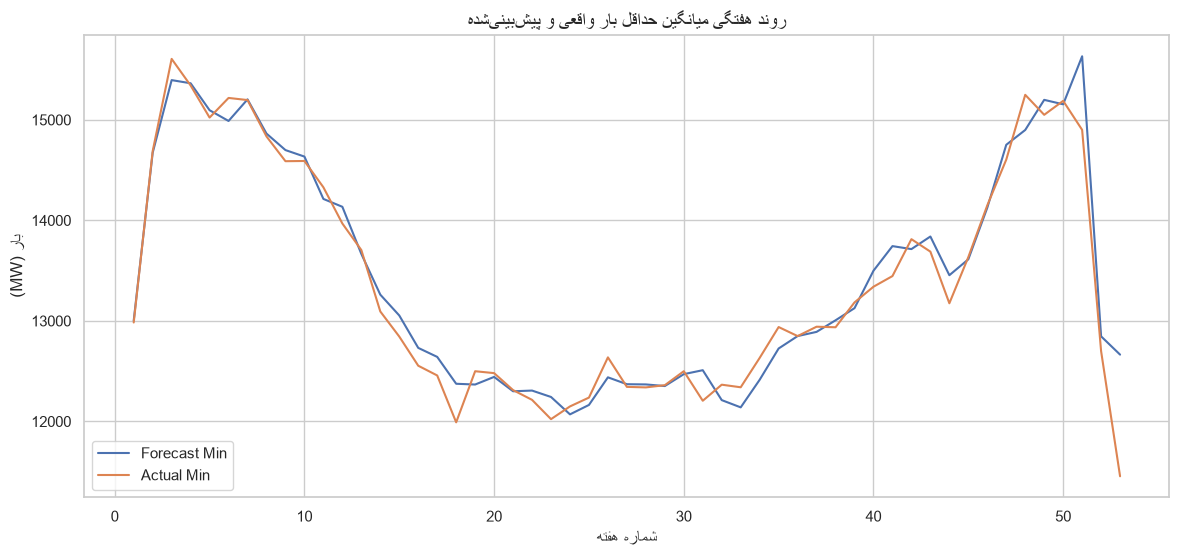

In [13]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=weekly_summary, x="week_number", y="avg_forecast_min", label="Forecast Min")
sns.lineplot(data=weekly_summary, x="week_number", y="avg_actual_min", label="Actual Min")
plt.title("روند هفتگی میانگین حداقل بار واقعی و پیش‌بینی‌شده")
plt.xlabel("شماره هفته")
plt.ylabel("بار (MW)")
plt.legend()
plt.show()


<div dir = "rtl">

### نمودار روند هفتگی حداکثر بار

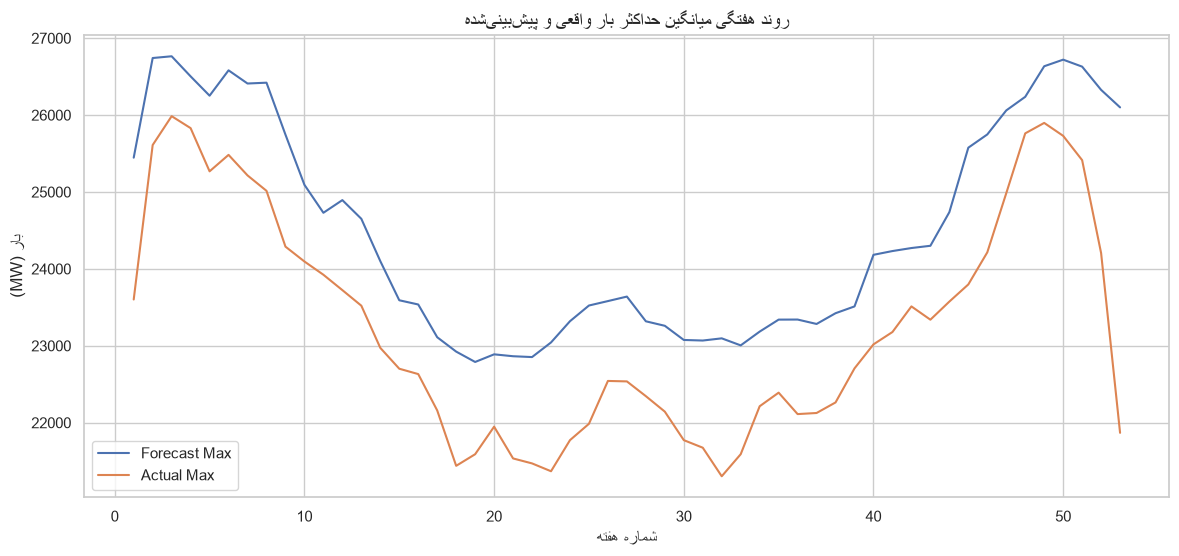

In [14]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=weekly_summary, x="week_number", y="avg_forecast_max", label="Forecast Max")
sns.lineplot(data=weekly_summary, x="week_number", y="avg_actual_max", label="Actual Max")
plt.title("روند هفتگی میانگین حداکثر بار واقعی و پیش‌بینی‌شده")
plt.xlabel("شماره هفته")
plt.ylabel("بار (MW)")
plt.legend()
plt.show()


<div dir = "rtl">

### مقایسه مستقیم forecast و actual

در نمودار scatter اگر نقاط نزدیک خط قطری باشند، یعنی پیش‌بینی به مقادیر واقعی نزدیک است.

اگر پراکندگی زیاد باشد، یعنی خطای پیش‌بینی بیشتر است.

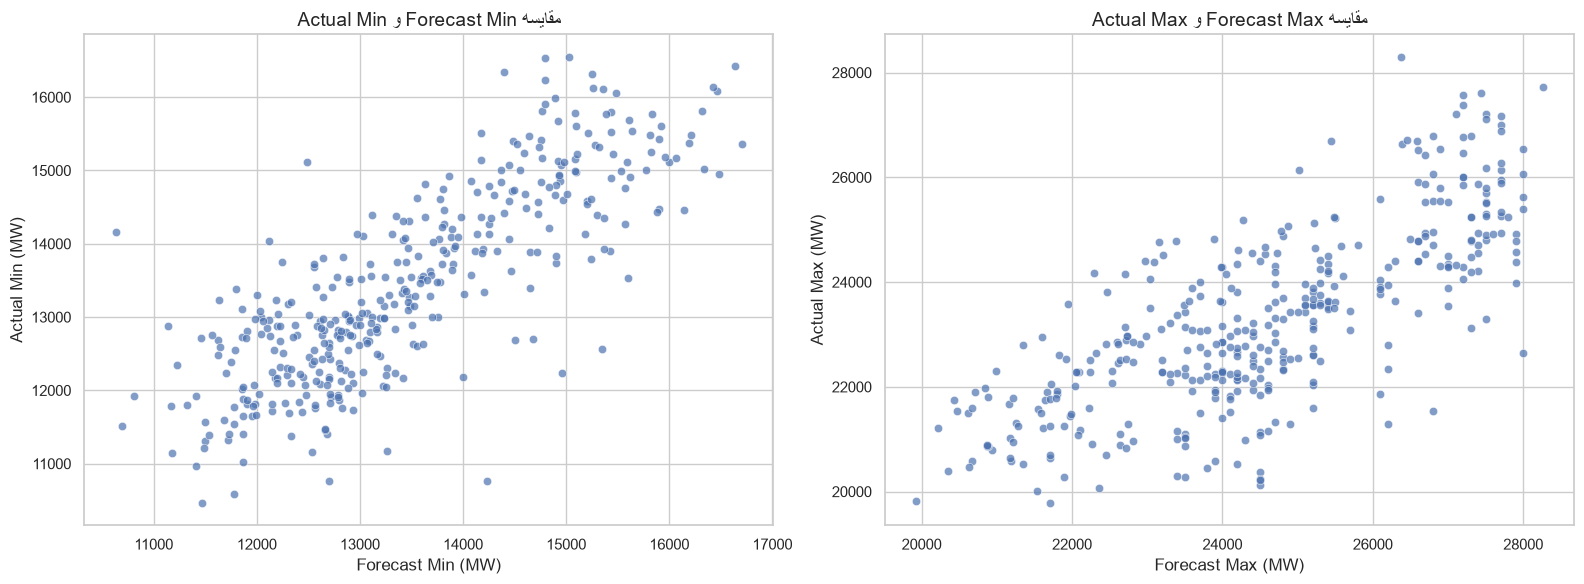

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df, x="forecast_min_mw", y="actual_min_mw", alpha=0.7, ax=axes[0])
axes[0].set_title("مقایسه Forecast Min و Actual Min")
axes[0].set_xlabel("Forecast Min (MW)")
axes[0].set_ylabel("Actual Min (MW)")

sns.scatterplot(data=df, x="forecast_max_mw", y="actual_max_mw", alpha=0.7, ax=axes[1])
axes[1].set_title("مقایسه Forecast Max و Actual Max")
axes[1].set_xlabel("Forecast Max (MW)")
axes[1].set_ylabel("Actual Max (MW)")

plt.tight_layout()
plt.show()


<div dir = "rtl">

###  اختلاف بین min/max واقعی و پیش‌بینی‌شده

ما فقط نمی‌خواهیم بدانیم بار واقعی چقدر بوده، بلکه می‌خواهیم بدانیم:

-    حداقل بار واقعی چقدر با حداقل بار پیش‌بینی‌شده فرق داشته
-    حداکثر بار واقعی چقدر با حداکثر بار پیش‌بینی‌شده فرق داشته

این اختلاف‌ها برای ارزیابی کیفیت پیش‌بینی بسیار مهم هستند.

In [16]:
diff_summary = df[[
    "error_min_mw",
    "error_max_mw",
    "abs_error_min_mw",
    "abs_error_max_mw",
    "pct_error_min",
    "pct_error_max"
]].describe()

diff_summary


,error_min_mw,error_max_mw,abs_error_min_mw,abs_error_max_mw,pct_error_min,pct_error_max
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,-37.853028,-1267.792069,595.383992,1495.308885,-0.117398,-4.956195
std,800.607673,1337.386783,535.742905,1076.263755,6.027439,5.319217
min,-3462.870000,-5356.870000,0.738000,4.784000,-24.332261,-19.613993
25%,-461.949000,-2192.722500,182.995000,519.668500,-3.452819,-8.521704
50%,-59.176500,-1392.565000,471.915000,1439.315000,-0.448596,-5.536733
75%,472.520000,-148.772750,866.582500,2192.722500,3.470792,-0.680061
max,3524.190000,1925.880000,3524.190000,5356.870000,33.148880,8.391568


<div dir = "rtl">

### نمودار توزیع خطاها

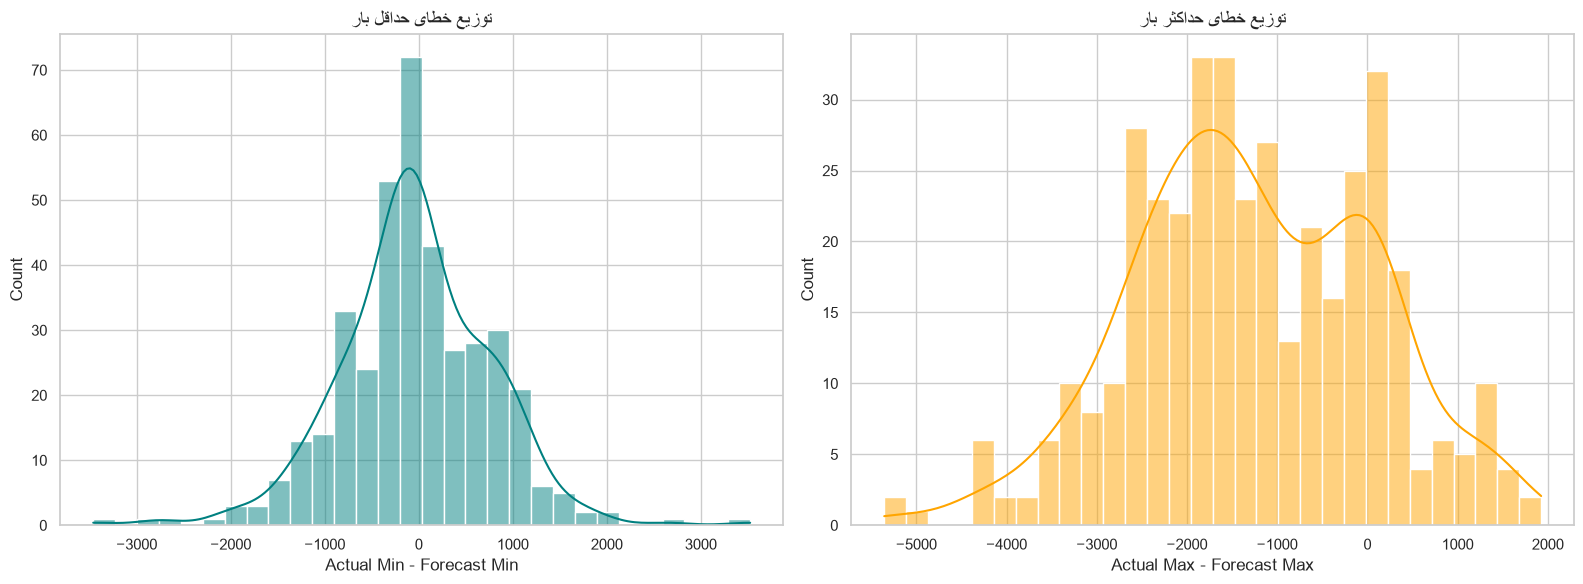

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df["error_min_mw"], bins=30, kde=True, ax=axes[0], color="teal")
axes[0].set_title("توزیع خطای حداقل بار")
axes[0].set_xlabel("Actual Min - Forecast Min")

sns.histplot(df["error_max_mw"], bins=30, kde=True, ax=axes[1], color="orange")
axes[1].set_title("توزیع خطای حداکثر بار")
axes[1].set_xlabel("Actual Max - Forecast Max")

plt.tight_layout()
plt.show()


<div dir = "rtl">

### تحلیل خطا به تفکیک سال

در این پروژه چند نوع خطا را بررسی می‌کنیم:

-    Error: اختلاف ساده
-    Absolute Error: قدرمطلق اختلاف
-    Percentage Error: اختلاف درصدی

این سه دیدگاه مختلف به ما کمک می‌کنند عملکرد سیستم پیش‌بینی را بهتر بسنجیم.

In [18]:
year_error_summary = df.groupby("data_year").agg(
    mae_min=("abs_error_min_mw", "mean"),
    mae_max=("abs_error_max_mw", "mean"),
    mean_error_min=("error_min_mw", "mean"),
    mean_error_max=("error_max_mw", "mean"),
    mape_min=("pct_error_min", lambda x: np.nanmean(np.abs(x))),
    mape_max=("pct_error_max", lambda x: np.nanmean(np.abs(x))),
).reset_index()

year_error_summary


,data_year,mae_min,mae_max,mean_error_min,mean_error_max,mape_min,mape_max
0,2019,501.265577,1796.873654,-68.200192,-1783.443654,3.590342,6.958528
1,2021,604.112264,2677.537547,-291.130755,-2677.537547,4.463980,10.412395
2,2022,918.250000,1693.834615,894.573462,-1681.546923,7.255295,6.569483
3,2023,544.209231,1218.554231,-2.581923,-1199.943462,3.894723,4.877893
4,2024,659.859923,1471.720067,-153.549038,-815.738298,4.859406,6.024681
5,2025,489.529135,758.181346,-426.227827,-601.257385,3.763590,3.318517
6,2027,191.775481,255.023185,-152.320741,133.842074,1.457804,1.118625


<div dir = "rtl">

### نمودار خطا به تفکیک سال

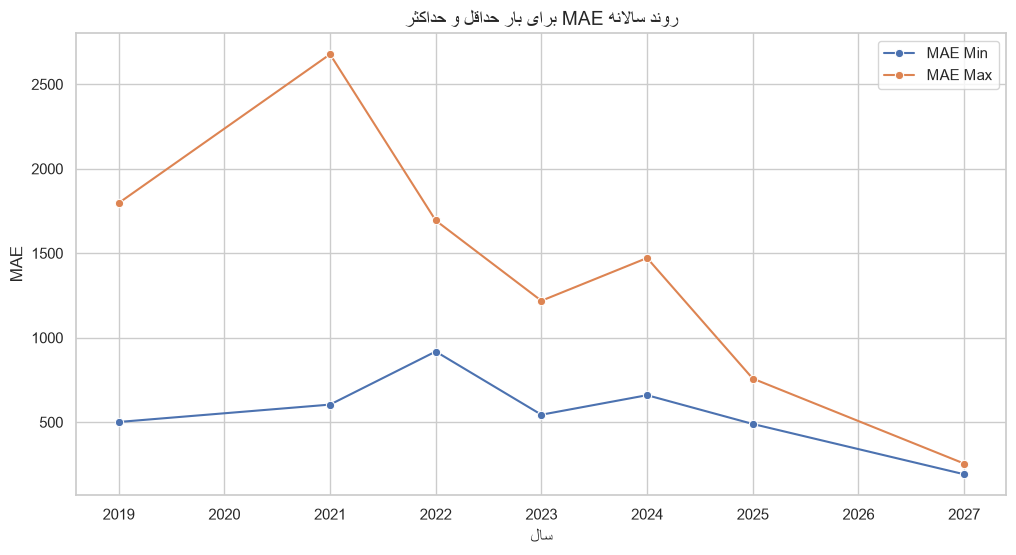

In [19]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=year_error_summary, x="data_year", y="mae_min", marker="o", label="MAE Min")
sns.lineplot(data=year_error_summary, x="data_year", y="mae_max", marker="o", label="MAE Max")
plt.title("روند سالانه MAE برای بار حداقل و حداکثر")
plt.xlabel("سال")
plt.ylabel("MAE")
plt.legend()
plt.show()


<div dir = "rtl">

### تحلیل خطا به تفکیک هفته

In [20]:
week_error_summary = df.groupby("week_number").agg(
    mae_min=("abs_error_min_mw", "mean"),
    mae_max=("abs_error_max_mw", "mean"),
    mape_min=("pct_error_min", lambda x: np.nanmean(np.abs(x))),
    mape_max=("pct_error_max", lambda x: np.nanmean(np.abs(x))),
).reset_index()

week_error_summary.head()


,week_number,mae_min,mae_max,mape_min,mape_max
0,1,432.581750,2638.401625,3.404266,9.883019
1,2,714.064875,1754.724125,4.786363,6.503181
2,3,653.900875,1236.832625,4.280043,4.561856
3,4,510.910875,926.900000,3.352876,3.448734
4,5,469.009875,1395.889625,3.070022,5.182844


<div dir = "rtl">

### نمودار خطا به تفکیک هفته

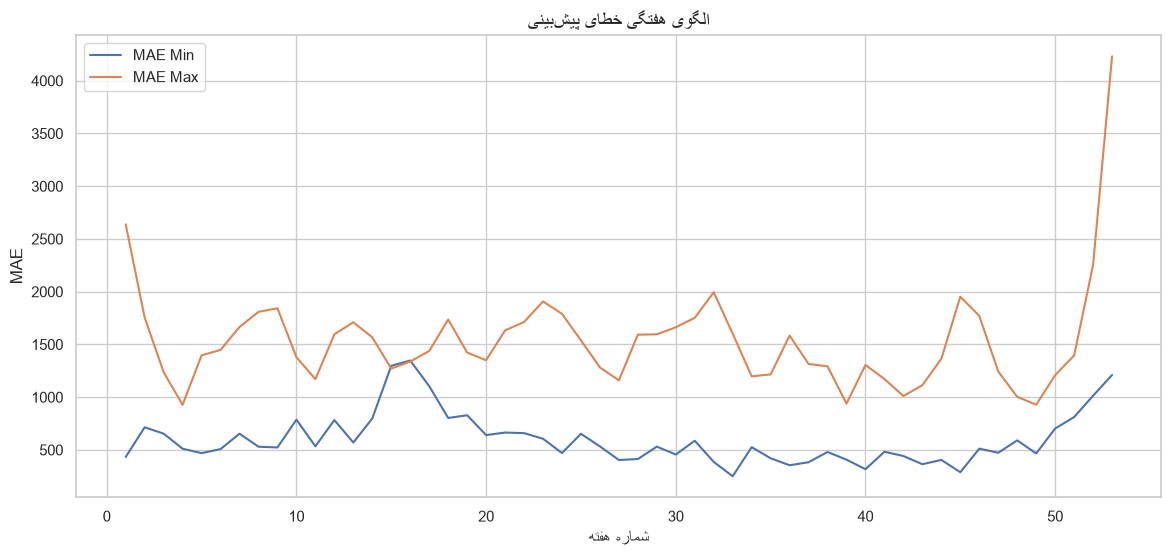

In [21]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=week_error_summary, x="week_number", y="mae_min", label="MAE Min")
sns.lineplot(data=week_error_summary, x="week_number", y="mae_max", label="MAE Max")
plt.title("الگوی هفتگی خطای پیش‌بینی")
plt.xlabel("شماره هفته")
plt.ylabel("MAE")
plt.legend()
plt.show()


<div dir = "rtl">

### تحلیل نوسان‌پذیری

یکی از سوال‌های مهم این است که کدام بخش داده نوسان بیشتری دارد.

برای این کار از انحراف معیار (std) و همچنین دامنه بار (max - min) استفاده می‌کنیم.

In [22]:
volatility_summary = df.groupby("data_year").agg(
    std_actual_min=("actual_min_mw", "std"),
    std_actual_max=("actual_max_mw", "std"),
    std_forecast_min=("forecast_min_mw", "std"),
    std_forecast_max=("forecast_max_mw", "std"),
    mean_actual_range=("actual_range_mw", "mean"),
    mean_forecast_range=("forecast_range_mw", "mean"),
).reset_index()

volatility_summary


,data_year,std_actual_min,std_actual_max,std_forecast_min,std_forecast_max,mean_actual_range,mean_forecast_range
0,2019,1108.351089,1198.966022,1247.415643,1645.121679,9951.196923,11666.440385
1,2021,1302.434122,1663.540995,1167.093980,1584.265888,9693.664906,12080.071698
2,2022,1182.137937,1529.866634,1299.648108,1169.888355,10135.004615,12711.125000
3,2023,1216.344364,1558.787367,1239.201152,1327.142964,9849.286538,11046.648077
4,2024,1225.129045,1725.740634,1280.175419,2070.207269,9781.003048,10443.192308
5,2025,1208.514424,1618.005022,1157.494766,1326.478525,9698.508904,9873.538462
6,2027,1626.361146,2418.812172,1489.420593,2108.688243,10226.125778,9863.075472


<div dir = "rtl">

### نمودار نوسان‌پذیری

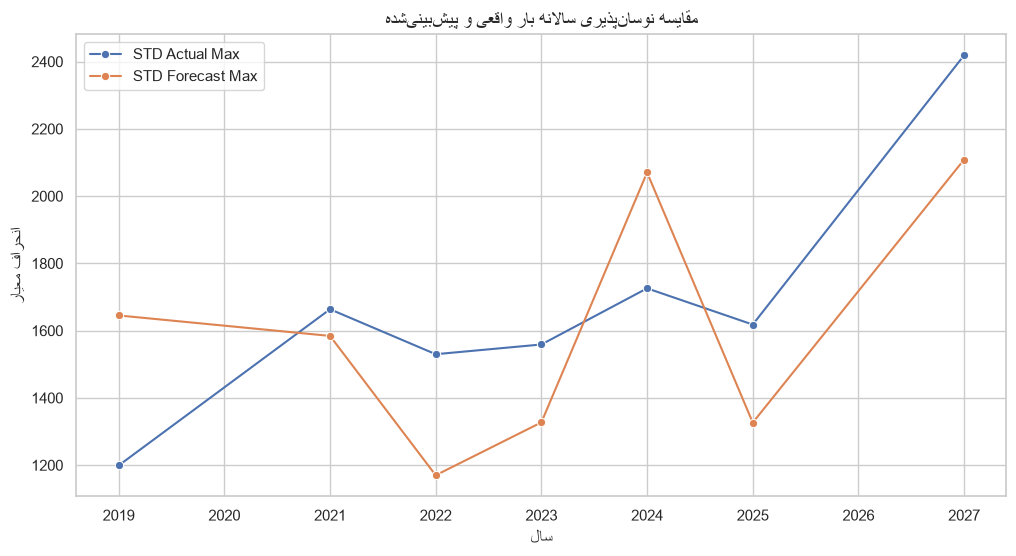

In [23]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=volatility_summary, x="data_year", y="std_actual_max", marker="o", label="STD Actual Max")
sns.lineplot(data=volatility_summary, x="data_year", y="std_forecast_max", marker="o", label="STD Forecast Max")
plt.title("مقایسه نوسان‌پذیری سالانه بار واقعی و پیش‌بینی‌شده")
plt.xlabel("سال")
plt.ylabel("انحراف معیار")
plt.legend()
plt.show()


<div dir = "rtl">

### الگوی فصلی تقریبی بر اساس شماره هفته

اگر نمودارهای هفتگی شکل تکرارشونده‌ای داشته باشند، می‌توان گفت داده دارای الگوی فصلی است.

این موضوع در فاز Feature Engineering و Modeling اهمیت زیادی خواهد داشت.

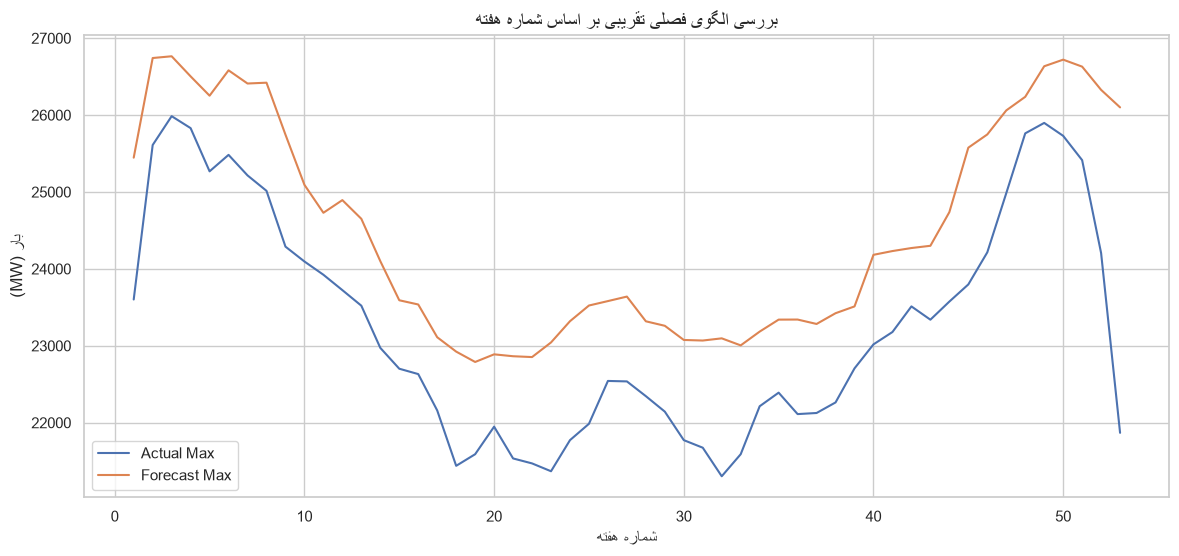

In [24]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=weekly_summary, x="week_number", y="avg_actual_max", label="Actual Max")
sns.lineplot(data=weekly_summary, x="week_number", y="avg_forecast_max", label="Forecast Max")
plt.title("بررسی الگوی فصلی تقریبی بر اساس شماره هفته")
plt.xlabel("شماره هفته")
plt.ylabel("بار (MW)")
plt.legend()
plt.show()


<div dir = "rtl">

### جدول خلاصه نهایی EDA

In [25]:
eda_summary = {
    "rows": len(df),
    "years": sorted(df["data_year"].dropna().unique().tolist()),
    "areas": sorted(df["area_code"].dropna().unique().tolist()),
    "avg_abs_error_min": df["abs_error_min_mw"].mean(),
    "avg_abs_error_max": df["abs_error_max_mw"].mean(),
    "avg_actual_range": df["actual_range_mw"].mean(),
    "avg_forecast_range": df["forecast_range_mw"].mean(),
}

eda_summary


{'rows': 418,
 'years': [2019, 2021, 2022, 2023, 2024, 2025, 2027],
 'areas': ['PL'],
 'avg_abs_error_min': np.float64(595.3839923469387),
 'avg_abs_error_max': np.float64(1495.3088852040812),
 'avg_actual_range': np.float64(9867.504581632653),
 'avg_forecast_range': np.float64(11015.698325358853)}